In [1]:
import matplotlib.pyplot as plt

%matplotlib inline


In [2]:
import numpy as np
import healpy as hp
from astropy.coordinates import SkyCoord
from astropy.coordinates import Angle
from astropy import units as u
from pylab import cm
import matplotlib.pyplot as plt
import matplotlib as mpl
import pickle
import pygplates
import random

In [3]:
def cat_to_hpx(lon, lat, nside, radec=True):
    
    """
    Converts a catalogue to a HEALPix map of number density i.e. 
    Number of stars per square degrees of sky.

    Parameters
    ----------
    lon, lat : (ndarray, ndarray)
        Coordinates of the sources in degree. 
        If radec=True, assume input is in the icrs system,
        Otherwise assume input is galactic latitude and longitude.


    nside : int
        HEALPix nside of the target map, defines the number of pixels.

    radec : bool
        Switch between Ra/Dec and l/b (galactic) as input coordinate system.

    Return
    ------
    hpx_map : ndarray
        HEALPix map of the catalogue number counts in Galactic coordinates

    """

    npix = hp.nside2npix(nside)

    if radec:
        eq = SkyCoord(lon, lat, unit='deg')
        l, b = eq.galactic.l.value, eq.galactic.b.value
    else:
        l, b = lon, lat
        
    # convert to theta, phi -> galactic longitude and colatitude in sphererical system
    theta = np.radians(90. - b)
    phi = np.radians(l)

    # convert to HEALPix indices
    indices = hp.ang2pix(nside, theta, phi)

    indx, counts = np.unique(indices, return_counts=True)

    # fill the fullsky map
    hpx_map = np.zeros(npix, dtype=int)
    hpx_map[indx] = counts

    return hpx_map

In [4]:
with open('gaia_stars.pickle', 'rb') as f:
    # The protocol version used is detected automatically, so we do not have to specify it.
    stars = pickle.load(f)

stars_RA = []
stars_DEC = []
stars_GID = []
stars_RP = []
for star in stars:
    gaiaid, RA, DECL, rpmag, r_med_geo, r_lo_geo, r_hi_geo = star
    if 200 < r_lo_geo:
        stars_GID.append(gaiaid)
        stars_RA.append(RA)
        stars_DEC.append(DECL)
        stars_RP.append(rpmag)

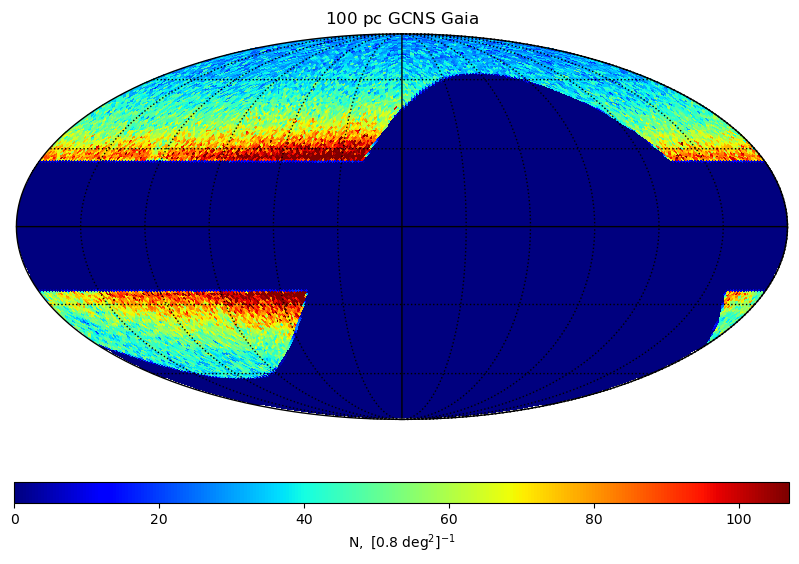

In [5]:
#input the nside, should be a number of 2**n
nside = 64

#call function to create Healpix map
hpx_map_gcns = cat_to_hpx(stars_RA, stars_DEC, nside=nside, radec=True)

#define a figure and size
f= plt.figure(figsize=(10,7))

#calculate the side of each pixel in square degrees
hpix_area = round(41253/len(np.arange(hp.nside2npix(nside),dtype=np.double)),1)   

#find minimum and maximum to normalise the colorbar
mmin, mmax = min((hpx_map_gcns)),max((hpx_map_gcns)) -40 #contribution from Hyades was strong, thus subtracted by random number (-40)

#add the desired 
cmap = cm.jet

#create a mollview projection from healpy and add custom colorbar and colormap
hp.mollview((hpx_map_gcns), hold=True, nest=False,cmap=cmap,min=mmin,max=mmax,notext=True,fig=1,
         cbar=False,title='$\mathrm{100 \ pc \ GCNS \ Gaia}$')

#add meridians and parallels
hp.graticule()

#create a colorbar axis
cax = f.add_axes([0.125, 0.1, 0.775, 0.03])

#create a colorbar and normalise it
cb = mpl.colorbar.ColorbarBase(cax,cmap=cmap,norm=mpl.colors.Normalize(vmin=mmin,vmax=mmax),
                               orientation='horizontal')

#add label to colorbar
cb.set_label(r'$\mathrm{ N, \ [}$'+str(hpix_area)+'$\mathrm{\ deg^2]^{-1}}$',fontsize=10)
cb.solids.set_edgecolor("face")
plt.show()

In [6]:
NSIDE = 32
print(
    "Approximate resolution at NSIDE {} is {:.2} deg".format(
        NSIDE, hp.nside2resol(NSIDE, arcmin=True) / 60
    )
)

Approximate resolution at NSIDE 32 is 1.8 deg


In [7]:
NPIX = hp.nside2npix(NSIDE)
print(NPIX)

12288


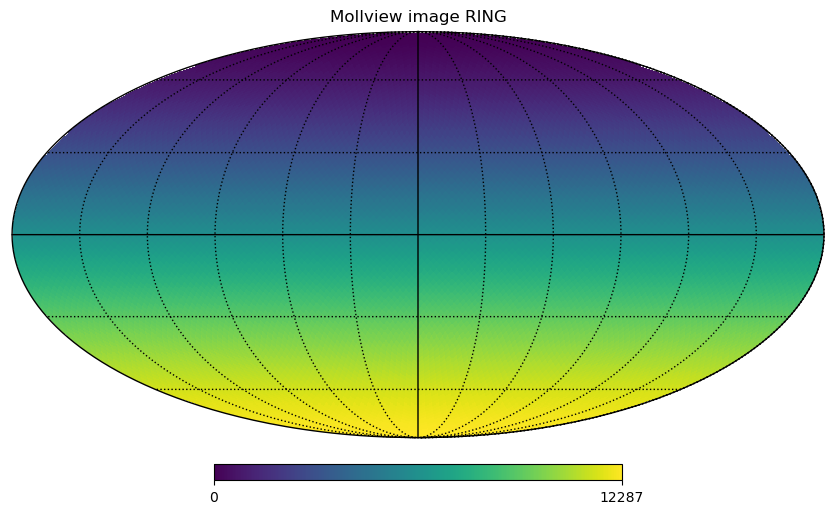

In [8]:
m = np.arange(NPIX)
hp.mollview(m, title="Mollview image RING")
hp.graticule()

In [9]:
diff_map = hp.read_map("./diff_ebv_gnilc_lenz.fits")

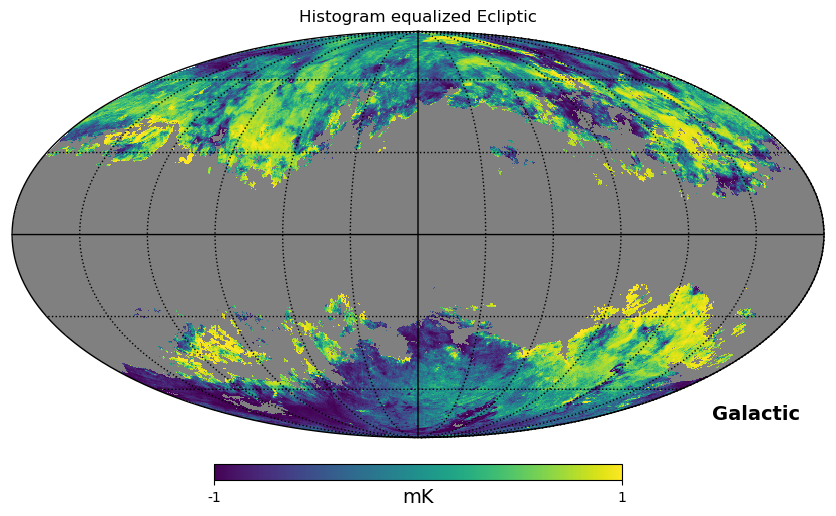

In [10]:
hp.mollview(
    diff_map,
    coord="G",
    title="Histogram equalized Ecliptic",
    unit="mK",
    norm="hist",
    min=-1,
    max=1,
)
hp.graticule()

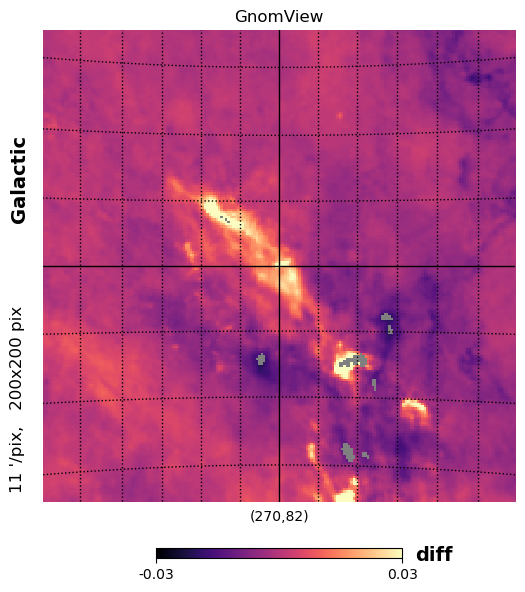

In [11]:
hp.gnomview(diff_map, rot=[270, 82], min=-0.03, max=0.03, cmap='magma',
            coord='G', reso=11, title="GnomView", unit="diff", format="%.2g")
hp.graticule()

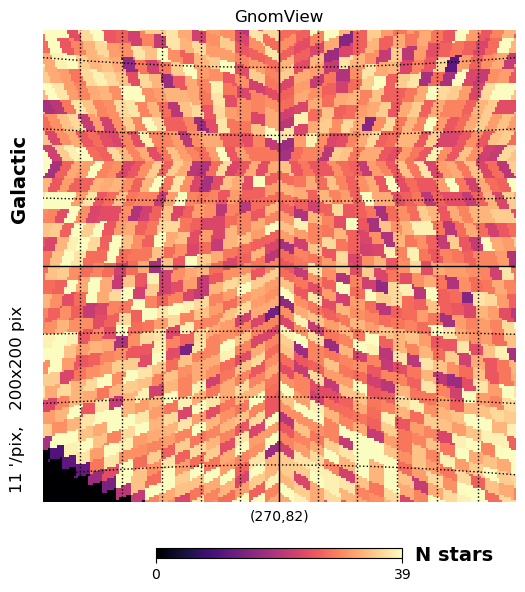

In [12]:
mmin = 0
mmax = 39
cmap = cm.magma

hp.gnomview(hpx_map_gcns, rot=[270, 82], min=mmin, max=mmax, cmap=cmap,
            coord='G', reso=11, title="GnomView", unit="N stars", format="%.2g")
hp.graticule()


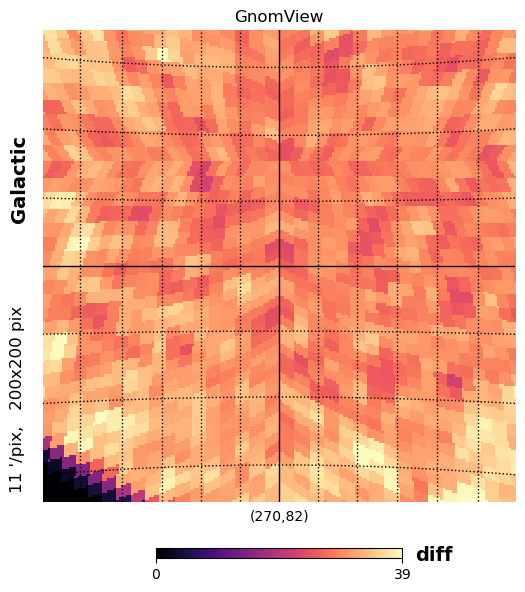

In [13]:
#smooth it using a gaussian of 0.2 radians
hpx_map_smooth = hp.sphtfunc.smoothing(hpx_map_gcns, sigma=0.01)
hpix_area = round(41253/len(np.arange(hp.nside2npix(nside),dtype=np.double)),1)   

#find minimum and maximum to normalise the colorbar
mmin, mmax = min((hpx_map_smooth)),max((hpx_map_smooth))

#add the desired 
cmap = cm.magma
hp.gnomview(hpx_map_smooth, rot=[270, 82], min=0, max=39, cmap='magma',
            coord='G', reso=11, title="GnomView", unit="diff", format="%.2g")
hp.graticule()

In [14]:
def cat_to_gal(lon, lat, GID, RPmag, radec=True):
    
    """
    Converts a catalogue to a HEALPix map of number density i.e. 
    Number of stars per square degrees of sky.

    Parameters
    ----------
    lon, lat : (ndarray, ndarray)
        Coordinates of the sources in degree. 
        If radec=True, assume input is in the icrs system,
        Otherwise assume input is galactic latitude and longitude.


    nside : int
        HEALPix nside of the target map, defines the number of pixels.

    radec : bool
        Switch between Ra/Dec and l/b (galactic) as input coordinate system.

    Return
    ------
    hpx_map : ndarray
        HEALPix map of the catalogue number counts in Galactic coordinates

    """

    npix = hp.nside2npix(nside)
    stars_l = []
    stars_b = []
    stars_ra = []
    stars_dec = []
    stars_gid = []
    stars_rp = []
    if radec:
        eq = SkyCoord(lon, lat, unit='deg')
        l, b = eq.galactic.l.value, eq.galactic.b.value
    else:
        l, b = lon, lat
        

    for i in range(len(l)):
        if 220.0 < l[i] and l[i] < 359.99 and 65.0 < b[i] and b[i] < 89.0:
            #stars_l.append(Angle(l, unit=u.deg))
            #stars_b.append(Angle(b, unit=u.deg))
            stars_l.append(l[i])
            stars_b.append(b[i])
            stars_ra.append(lon[i])
            stars_dec.append(lat[i])
            stars_gid.append(GID[i])
            stars_rp.append(RPmag[i])
    
    return stars_l, stars_b, stars_ra, stars_dec, stars_gid, stars_rp

/run/media/dima/lindata/Installed/miniconda3/envs/mark_skyplot/lib/python3.11/site-packages/healpy/visufunc.py:468: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  f = pylab.figure(fig, figsize=(5.8, 6.4))


1778


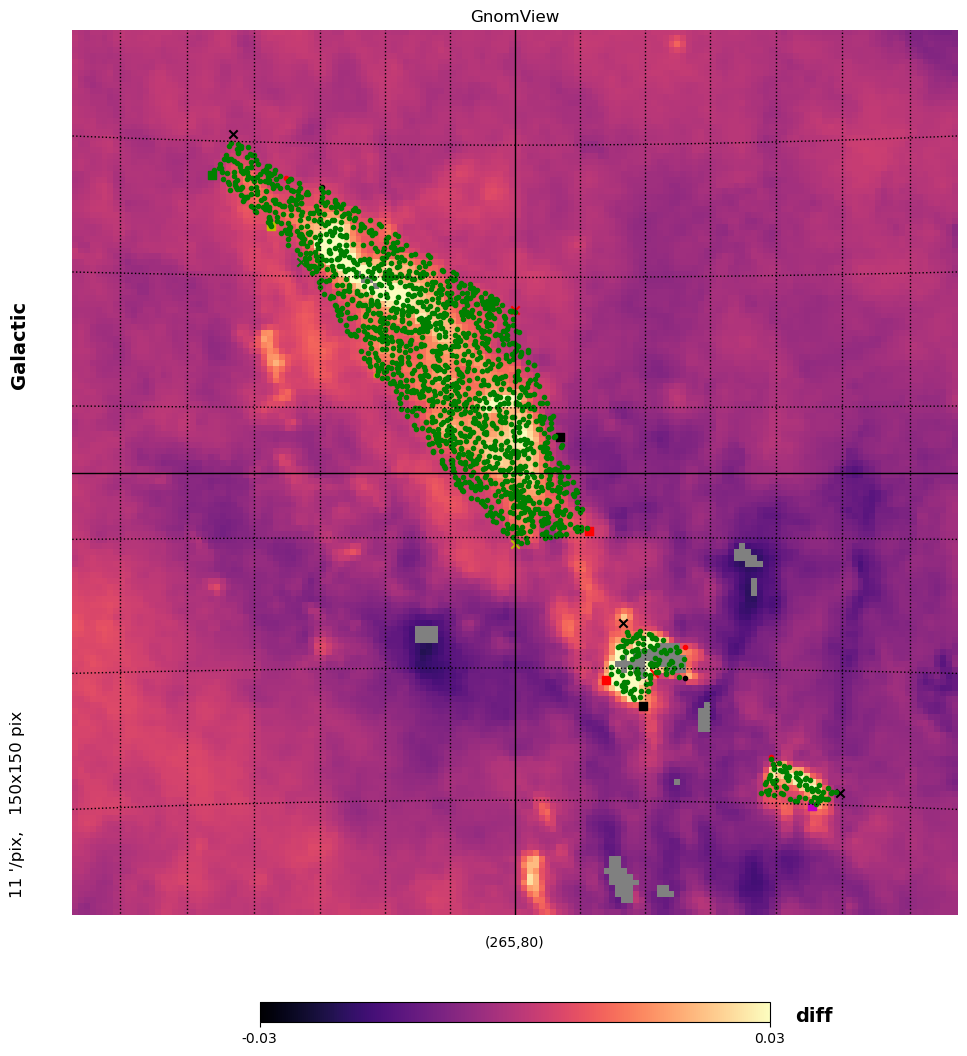

In [15]:
f= plt.figure(figsize=(12,12))


hp.gnomview(diff_map, rot=[265, 80], min=-0.03, max=0.03, cmap='magma',
            xsize=150, ysize=150, fig=1,
            coord='G', reso=11, title="GnomView", unit="diff", format="%.2g")
hp.graticule()

p1 = (357.2, 81.5)
p2 = (347.0, 83.0)
p3 = (343.0, 84.0)
p4 = (265.0, 85.0)
p5 = (256.0, 81.0)
p6 = (254.0, 78.0)
hp.projscatter(p1[0], p1[1], marker='x', c='k', lonlat=True, coord='G')
hp.projscatter(p2[0], p2[1], marker='.', c='r', lonlat=True, coord='G')
hp.projscatter(p3[0], p3[1], marker='.', c='k', lonlat=True, coord='G')
hp.projscatter(p4[0], p4[1], marker='x', c='r', lonlat=True, coord='G')
hp.projscatter(p5[0], p5[1], marker='s', c='k', lonlat=True, coord='G')
hp.projscatter(p6[0], p6[1], marker='s', c='r', lonlat=True, coord='G')

p7 = (265.0, 77.8)
p8 = (275.0, 79.5)
p9 = (296.5, 81.8)
p10 = (326.7, 82.6)
p11 = (337.0, 82.2)
p12 = (349.5, 80.8)

hp.projscatter(p7[0], p7[1], marker='x', c='y', lonlat=True, coord='G')
hp.projscatter(p8[0], p8[1], marker='.', c='g', lonlat=True, coord='G')
hp.projscatter(p9[0], p9[1], marker='.', c='y', lonlat=True, coord='G')
hp.projscatter(p10[0], p10[1], marker='x', c='g', lonlat=True, coord='G')
hp.projscatter(p11[0], p11[1], marker='s', c='y', lonlat=True, coord='G')
hp.projscatter(p12[0], p12[1], marker='s', c='g', lonlat=True, coord='G')

stars_l, stars_b, stars_ra, stars_dec, stars_gid, stars_rp = cat_to_gal(stars_RA, stars_DEC,
                                                                        stars_GID, stars_RP,
                                                                        radec=True)

#hp.projscatter(stars_l, stars_b, marker='.', c='g', lonlat=True, coord='G')

# define polygon
point1 = pygplates.PointOnSphere(p1[1], p1[0])
point2 = pygplates.PointOnSphere(p2[1], p2[0])
point3 = pygplates.PointOnSphere(p3[1], p3[0])
point4 = pygplates.PointOnSphere(p4[1], p4[0])
point5 = pygplates.PointOnSphere(p5[1], p5[0])
point6 = pygplates.PointOnSphere(p6[1], p6[0])
point7 = pygplates.PointOnSphere(p7[1], p7[0])
point8 = pygplates.PointOnSphere(p8[1], p8[0])
point9 = pygplates.PointOnSphere(p9[1], p9[0])
point10 = pygplates.PointOnSphere(p10[1], p10[0])
point11 = pygplates.PointOnSphere(p11[1], p11[0])
point12 = pygplates.PointOnSphere(p12[1], p12[0])


exterior = [point1, point2, point3, point4, point5, point6,\
           point7, point8, point9, point10, point11, point12]

#polygon = pygplates.PolygonOnSphere(exterior)

#polygon = pygplates.PolygonOnSphere(exterior, interior_rings)
polygon = pygplates.PolygonOnSphere(exterior)



    
new_st_l = []
new_st_b = []
new_st_ra = []
new_st_dec = []
new_st_gid = []
new_st_rp = []
for i in range(len(stars_l)):
    point_test = pygplates.PointOnSphere(stars_b[i], stars_l[i])
    if polygon.is_point_in_polygon(point_test.to_lat_lon()):
        new_st_l.append(stars_l[i])
        new_st_b.append(stars_b[i])
        new_st_ra.append(stars_ra[i])
        new_st_dec.append(stars_dec[i])
        new_st_gid.append(stars_gid[i])
        new_st_rp.append(stars_rp[i])

        
# second smaller polygon
sp1 = (252.0, 75.0)
sp2 = (246.0, 73.8)
sp3 = (247.0, 72.9)
sp4 = (250.0, 73.3)
sp5 = (251.9, 72.4)
sp6 = (255.2, 73.4)
hp.projscatter(sp1[0], sp1[1], marker='x', c='k', lonlat=True, coord='G')
hp.projscatter(sp2[0], sp2[1], marker='.', c='r', lonlat=True, coord='G')
hp.projscatter(sp3[0], sp3[1], marker='.', c='k', lonlat=True, coord='G')
hp.projscatter(sp4[0], sp4[1], marker='x', c='r', lonlat=True, coord='G')
hp.projscatter(sp5[0], sp5[1], marker='s', c='k', lonlat=True, coord='G')
hp.projscatter(sp6[0], sp6[1], marker='s', c='r', lonlat=True, coord='G')
point1 = pygplates.PointOnSphere(sp1[1], sp1[0])
point2 = pygplates.PointOnSphere(sp2[1], sp2[0])
point3 = pygplates.PointOnSphere(sp3[1], sp3[0])
point4 = pygplates.PointOnSphere(sp4[1], sp4[0])
point5 = pygplates.PointOnSphere(sp5[1], sp5[0])
point6 = pygplates.PointOnSphere(sp6[1], sp6[0])
exterior = [point1, point2, point3, point4, point5, point6]
polygon = pygplates.PolygonOnSphere(exterior)

for i in range(len(stars_l)):
    point_test = pygplates.PointOnSphere(stars_b[i], stars_l[i])
    if polygon.is_point_in_polygon(point_test.to_lat_lon()):
        new_st_l.append(stars_l[i])
        new_st_b.append(stars_b[i])
        new_st_ra.append(stars_ra[i])
        new_st_dec.append(stars_dec[i])
        new_st_gid.append(stars_gid[i])
        new_st_rp.append(stars_rp[i])
        
# third even smaller polygon
ssp1 = (238.0, 68.0)
ssp2 = (242.0, 69.8)
ssp3 = (243.9, 68.9)
ssp4 = (240.5, 68.0)
hp.projscatter(ssp1[0], ssp1[1], marker='x', c='k', lonlat=True, coord='G')
hp.projscatter(ssp2[0], ssp2[1], marker='.', c='r', lonlat=True, coord='G')
hp.projscatter(ssp3[0], ssp3[1], marker='.', c='g', lonlat=True, coord='G')
hp.projscatter(ssp4[0], ssp4[1], marker='s', c='m', lonlat=True, coord='G')
point1 = pygplates.PointOnSphere(ssp1[1], ssp1[0])
point2 = pygplates.PointOnSphere(ssp2[1], ssp2[0])
point3 = pygplates.PointOnSphere(ssp3[1], ssp3[0])
point4 = pygplates.PointOnSphere(ssp4[1], ssp4[0])
exterior = [point1, point2, point3, point4]
polygon = pygplates.PolygonOnSphere(exterior)

for i in range(len(stars_l)):
    point_test = pygplates.PointOnSphere(stars_b[i], stars_l[i])
    if polygon.is_point_in_polygon(point_test.to_lat_lon()):
        new_st_l.append(stars_l[i])
        new_st_b.append(stars_b[i])
        new_st_ra.append(stars_ra[i])
        new_st_dec.append(stars_dec[i])
        new_st_gid.append(stars_gid[i])
        new_st_rp.append(stars_rp[i])

print(len(new_st_l))
hp.projscatter(new_st_l, new_st_b, marker='.', c='g', lonlat=True, coord='G')

In [16]:
# output the entire list 
fop = open('observing_list_entire.txt','w')
fop.write("#GID   RA    DEC     l     b     RP\n")
for i in range(len(new_st_l)):
    ostr = "{:d}".format(new_st_gid[i])
    ostr += "  {:.5f}".format(new_st_ra[i])
    ostr += "  {:.5f}".format(new_st_dec[i])
    ostr += "  {:.5f}".format(new_st_l[i])
    ostr += "  {:.5f}".format(new_st_b[i])
    ostr += "  {:.2f}\n".format(new_st_rp[i])
    fop.write(ostr)
fop.close()

In [17]:
# output N random stars
N = 300
indices = random.sample(range(0, len(new_st_l)), N)

final_st_l   = []
final_st_b   = []

fop = open('observing_list_small.txt','w')
fop.write("#GID   RA    DEC     l     b     RP\n")
for i in indices:
    ostr = "{:d}".format(new_st_gid[i])
    ostr += "  {:.5f}".format(new_st_ra[i])
    ostr += "  {:.5f}".format(new_st_dec[i])
    ostr += "  {:.5f}".format(new_st_l[i])
    ostr += "  {:.5f}".format(new_st_b[i])
    ostr += "  {:.2f}\n".format(new_st_rp[i])
    fop.write(ostr)
    final_st_l.append(new_st_l[i])
    final_st_b.append(new_st_b[i])
fop.close()



300


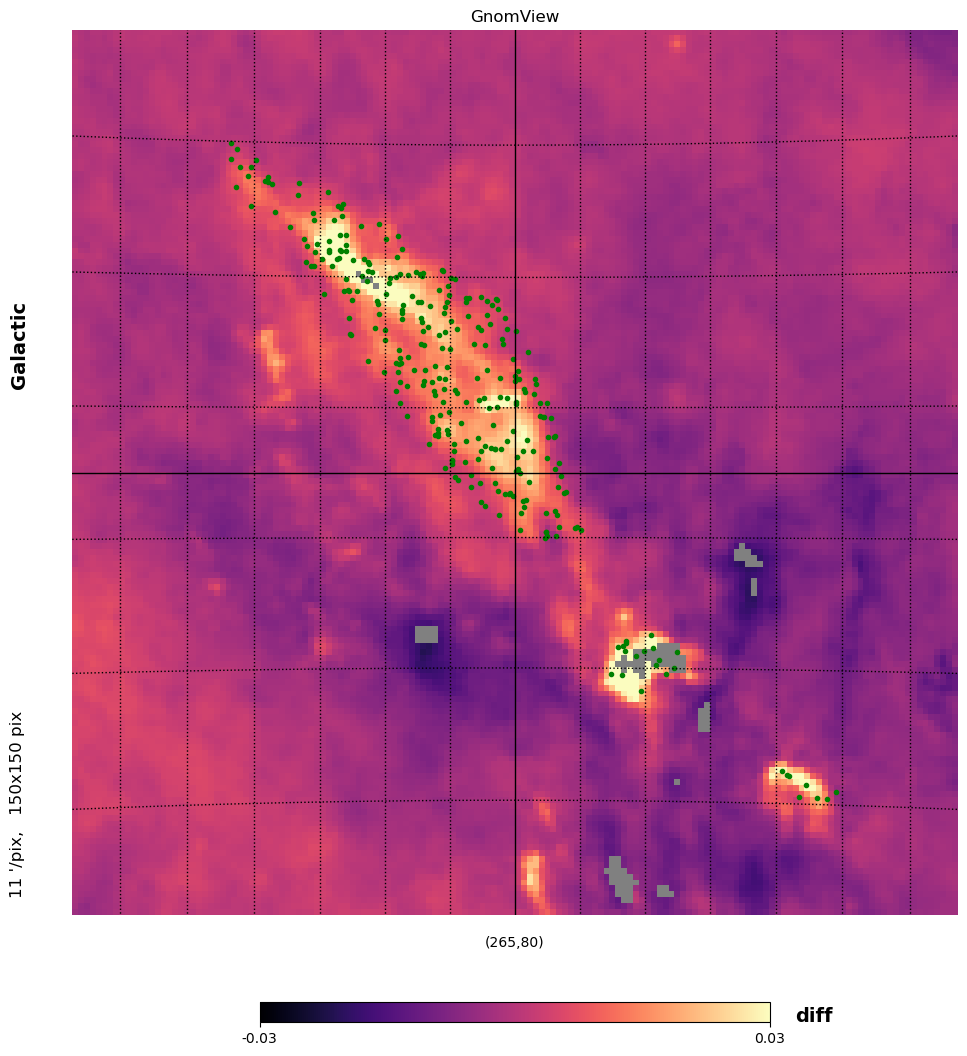

In [18]:
f= plt.figure(figsize=(12,12))


hp.gnomview(diff_map, rot=[265, 80], min=-0.03, max=0.03, cmap='magma',
            xsize=150, ysize=150, fig=1,
            coord='G', reso=11, title="GnomView", unit="diff", format="%.2g")
hp.graticule()

print(len(final_st_l))
hp.projscatter(final_st_l, final_st_b, marker='.', c='g', lonlat=True, coord='G')

<H1>UPD 2025: we observed 157 stars in 2024. Let's plot what is remaining.</H1>

In [22]:
# reading the external/agglomeration list
targ_done_l = []
targ_done_b = []
targ_remaining_l = []
targ_remaining_b = []
remaining_names = []
fop = open('./Markkanen_schedule.csv')
for line in fop.readlines():
    if line.startswith("#"):
        continue
    sl = line.split(',')
    ra = float(sl[1])
    dec = float(sl[2])
    remaining_names.append(sl[0])
    c = SkyCoord(ra, dec, unit="deg", frame="icrs")  # defaults to ICRS frame
    targ_remaining_l.append(c.galactic.l.degree)
    targ_remaining_b.append(c.galactic.b.degree)
fop.close()

In [23]:
# reading the external/agglomeration list
targ_all_l = []
targ_all_b = []
fop = open('./Markkanen_schedule_original.csv')
for line in fop.readlines():
    if line.startswith("#"):
        continue
    sl = line.split(',')
    ra = float(sl[1])
    dec = float(sl[2])
    name = sl[0]
    c = SkyCoord(ra, dec, unit="deg", frame="icrs")  # defaults to ICRS frame
    targ_all_l.append(c.galactic.l.degree)
    targ_all_b.append(c.galactic.b.degree)
    # is it already observed or not?
    if not name in remaining_names:
        targ_done_l.append(c.galactic.l.degree)
        targ_done_b.append(c.galactic.b.degree)
fop.close()

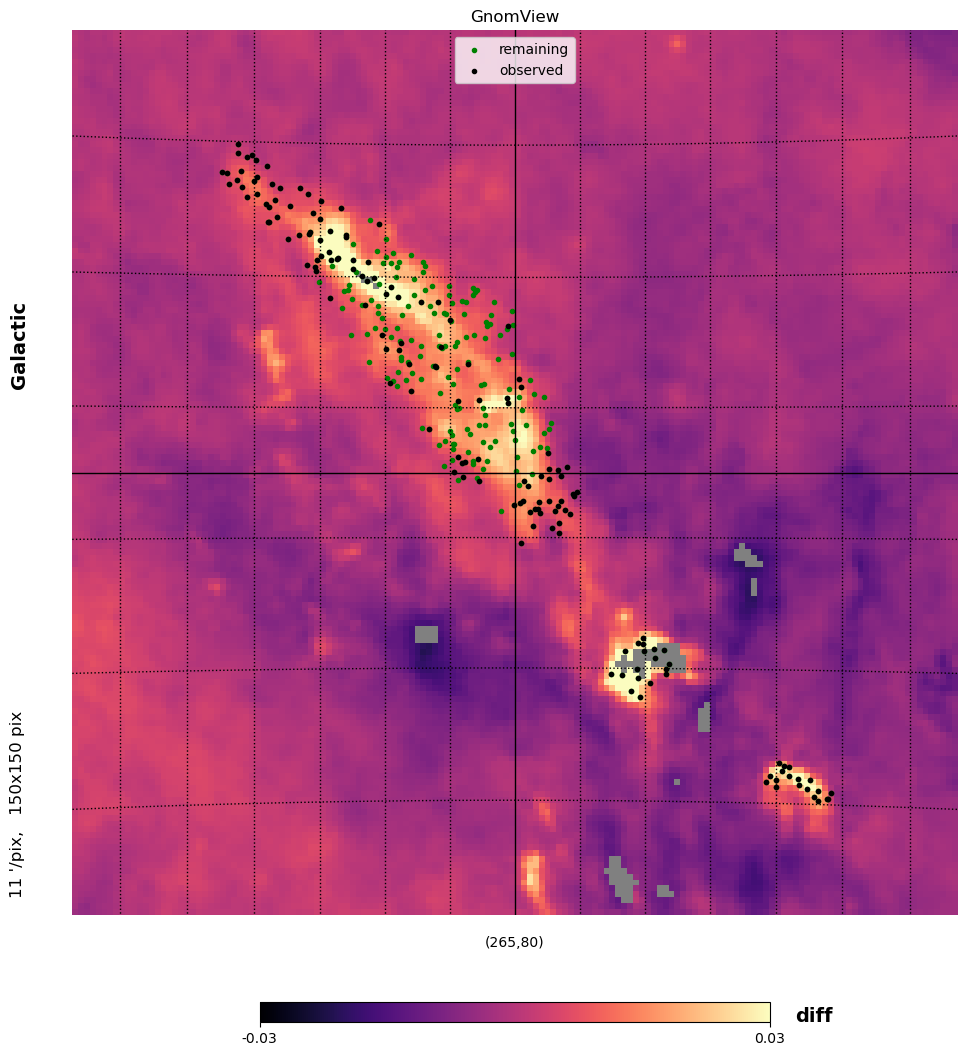

In [24]:
f= plt.figure(figsize=(12,12))


hp.gnomview(diff_map, rot=[265, 80], min=-0.03, max=0.03, cmap='magma',
            xsize=150, ysize=150, fig=1,
            coord='G', reso=11, title="GnomView", unit="diff", format="%.2g")
hp.graticule()


hp.projscatter(targ_all_l, targ_all_b, marker='.', c='g', lonlat=True, coord='G', label='remaining')
hp.projscatter(targ_done_l, targ_done_b, marker='.', c='k', lonlat=True, coord='G', label='observed')
plt.legend()
plt.savefig('mark_2025.png')